# Sales & Profitability Analysis


## Project Objective
The objective of this project is to analyze sales and profitability performance using the Superstore dataset. The analysis aims to identify underperforming categories, uncover factors affecting profitability, and provide business insights through SQL, Python EDA, and interactive dashboard visualization.

## 1. Import Libraries
Import the required Python libraries for data manipulation, visualization, and BigQuery integration.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from google.cloud import bigquery
from google.colab import auth

In [ ]:
auth.authenticate_user()

## 2. Connect to BigQuery
Create a BigQuery client to connect with the project.

In [ ]:
client = bigquery.Client(project='porto-495915')

## 3. Load Dataset
Retrieve sales transaction data from BigQuery.

In [ ]:
query = """
SELECT *
FROM `porto-495915.sales_data.sales_clean`
"""

df = client.query(query).to_dataframe()

df.head()

,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,...,Region,Product_ID,Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Cost,Profit
0,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,220.0464,41.9136
1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,512.3580,219.5820
2,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,7.7486,6.8714
3,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,1340.6085,-383.0310
4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,19.8516,2.5164


# 4. Analysis Context
Initial business analysis was performed using SQL in BigQuery. The SQL findings showed that Furniture was the least profitable category and Tables generated the largest losses. This notebook focuses on exploratory data analysis (EDA) to validate those findings and identify potential drivers of low profitability.

# 5. Data Overview
Understand the dataset structure, dimensions, and statistical characteristics before performing further analysis.

In [ ]:
df.shape

(9993, 21)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9993 entries, 0 to 9992
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       9993 non-null   object 
 1   Order_Date     9993 non-null   dbdate 
 2   Ship_Date      9993 non-null   dbdate 
 3   Ship_Mode      9993 non-null   object 
 4   Customer_ID    9993 non-null   object 
 5   Customer_Name  9993 non-null   object 
 6   Segment        9993 non-null   object 
 7   Country        9993 non-null   object 
 8   City           9993 non-null   object 
 9   State          9993 non-null   object 
 10  Postal_Code    9993 non-null   Int64  
 11  Region         9993 non-null   object 
 12  Product_ID     9993 non-null   object 
 13  Category       9993 non-null   object 
 14  Sub_Category   9993 non-null   object 
 15  Product_Name   9993 non-null   object 
 16  Sales          9993 non-null   float64
 17  Quantity       9993 non-null   Int64  
 18  Discount

In [ ]:
df.describe()

,Postal_Code,Sales,Quantity,Discount,Cost,Profit
count,9993.0,9993.000000,9993.0,9993.000000,9993.000000,9993.000000
mean,55191.576403,229.852846,3.789753,0.156188,201.191875,28.660971
std,32065.074478,623.276074,2.225149,0.206457,550.866205,234.271476
min,1040.0,0.444000,1.0,0.000000,0.554400,-6599.978000
25%,23223.0,17.280000,2.0,0.000000,12.688200,1.731000
50%,56560.0,54.480000,3.0,0.200000,41.664000,8.671000
75%,90008.0,209.940000,5.0,0.200000,182.220000,29.364000
max,99301.0,22638.480000,14.0,0.800000,24449.558400,8399.976000


# 6. Data Quality Validation
Verify data quality by checking missing values and duplicate records.

In [ ]:
df.isnull().sum()

,0
Order_ID,0
Order_Date,0
Ship_Date,0
Ship_Mode,0
Customer_ID,0
Customer_Name,0
Segment,0
Country,0
City,0
State,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df[df.duplicated(keep=False)]

,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,...,Region,Product_ID,Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Cost,Profit


### Key Finding
No significant missing values or duplicate records were identified. The dataset is suitable for further analysis.

# 7. Sales & Profit Distribution Analysis
Analyze the distribution of Sales and Profit to understand transaction patterns and identify potential outliers.

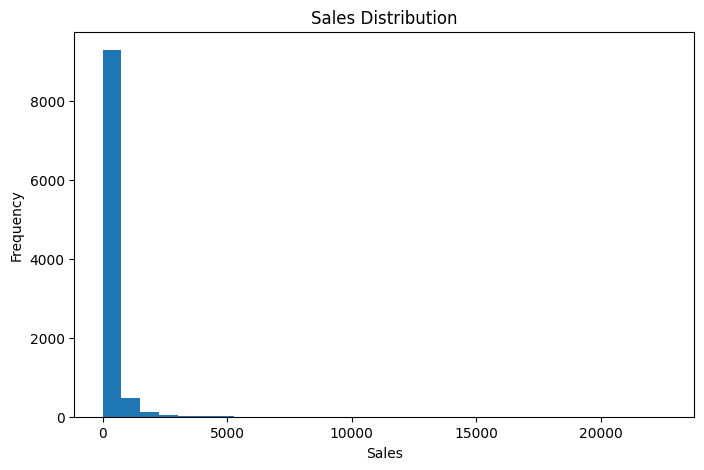

In [ ]:
# Sales distribution
plt.figure(figsize=(8,5))
plt.hist(df['Sales'], bins=30)

plt.title('Sales Distribution')
plt.xlabel('Sales')
plt.ylabel('Frequency')

plt.show()

###Insight
Sales distribution is highly right-skewed, indicating that most transactions generate relatively low sales while a small number of transactions contribute exceptionally high sales.

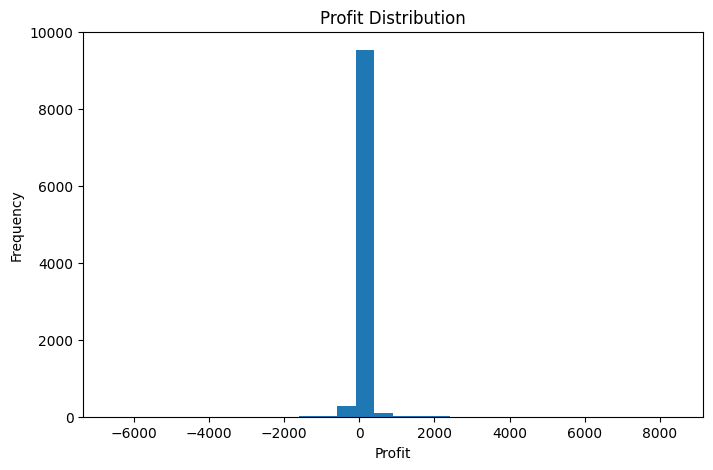

In [ ]:
# Profit distribution
plt.figure(figsize=(8,5))
plt.hist(df['Profit'], bins=30)

plt.title('Profit Distribution')
plt.xlabel('Profit')
plt.ylabel('Frequency')

plt.show()

### Insight
Most transactions generate modest profits, while a portion of transactions result in substantial losses.

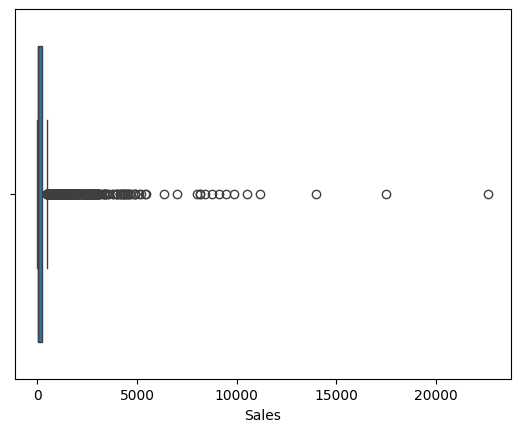

In [ ]:
# Sales Boxplot
sns.boxplot(x=df['Sales'])
plt.show()

### Insight
The Sales distribution contains several high-value outliers, indicating that a small number of transactions contribute disproportionately to total sales.

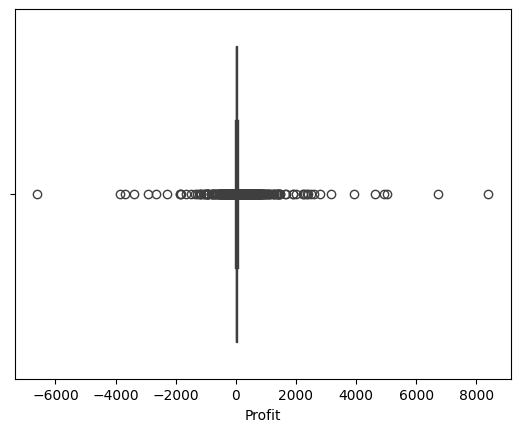

In [ ]:
# Profit boxplot
sns.boxplot(x=df['Profit'])
plt.show()

### Insight
The Profit distribution contains both extreme positive and negative outliers, suggesting substantial variation in transaction profitability.

# 8. Category Performance Analysis
Evaluate profitability across product categories to identify the strongest and weakest performing categories.

In [ ]:
# Profit by category
category_profit = (
    df.groupby('Category')['Profit']
      .sum()
      .sort_values(ascending=False)
)

category_profit

,Profit
Category,
Technology,145454.9481
Office Supplies,122490.8008
Furniture,18463.3316


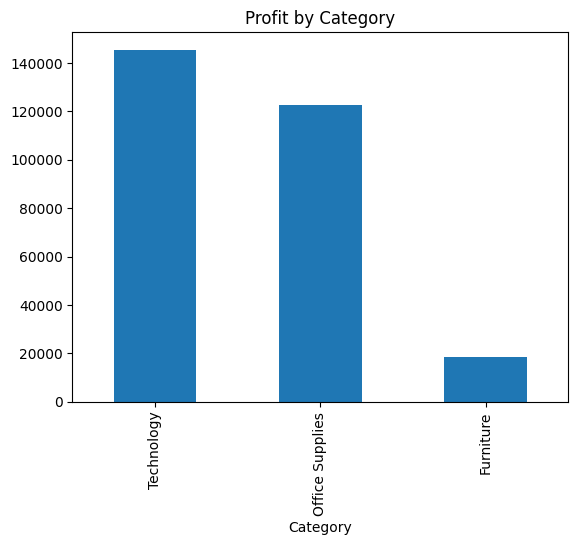

In [ ]:
# Visualization
category_profit.plot(kind='bar')

plt.title('Profit by Category')

plt.show()

### Insight
Technology generates the highest total profit, while furniture contributes the lowest profitability among all categories.

In [ ]:
# Profit margin by category
category_margin = (
    df.groupby('Category')
      .agg({
          'Sales':'sum',
          'Profit':'sum'
      })
)

category_margin['profit_margin'] = (
    category_margin['Profit'] /
    category_margin['Sales']
) * 100

category_margin

,Sales,Profit,profit_margin
Category,,,
Furniture,741718.4233,18463.3316,2.489264
Office Supplies,719047.0320,122490.8008,17.035158
Technology,836154.0330,145454.9481,17.395712


### Insight
Furniture has the lowest profit margin, indicating weaker profitability despite generating considerable sales.

# 9. Sub-category performance analysis
Drill down into sub-categories to identify specific areas contributing to low profitability.

In [ ]:
# Profit by sub-category
sub_profit = (
    df.groupby('Sub_Category')['Profit']
      .sum()
      .sort_values()
)

sub_profit

,Profit
Sub_Category,
Tables,-17725.4811
Bookcases,-3472.5560
Supplies,-1189.0995
Fasteners,949.5182
Machines,3384.7569
Labels,5546.2540
Art,6527.7870
Envelopes,6964.1767
Furnishings,13059.1436


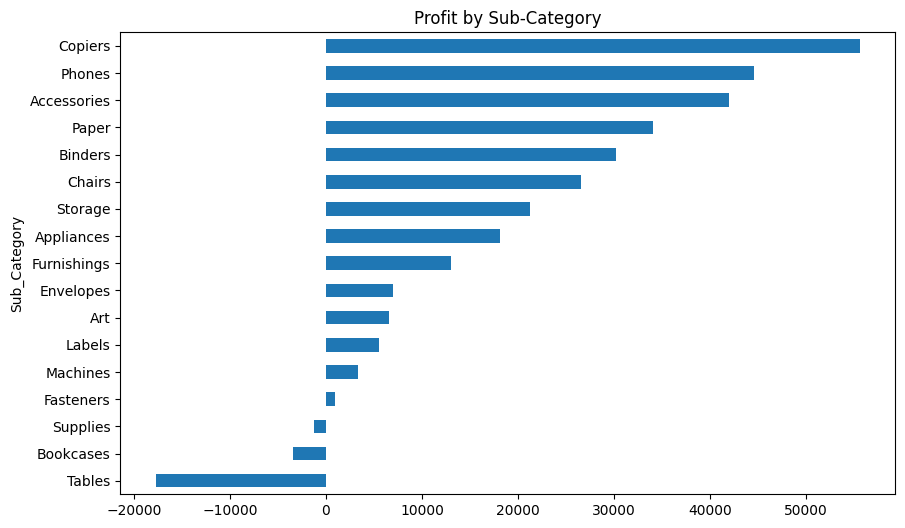

In [ ]:
# Visualization
plt.figure(figsize=(10,6))

sub_profit.plot(kind='barh')

plt.title('Profit by Sub-Category')

plt.show()

### Insight
Tables records the largest loss among all sub-categories, making it a key area of concern.

# 10. Discount impact analysis
Investigate whether discount levels contribute to reduced profitability.

In [ ]:
# Correlation analysis
corr = df[['Sales','Profit','Discount']].corr()

corr

,Sales,Profit,Discount
Sales,1.000000,0.479067,-0.028197
Profit,0.479067,1.000000,-0.219481
Discount,-0.028197,-0.219481,1.000000


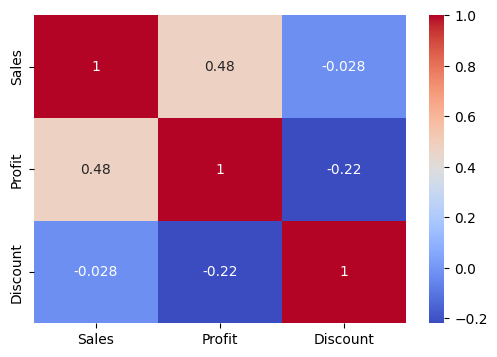

In [ ]:
# Correlation heatmap
plt.figure(figsize=(6,4))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.show()

### Insight
Discount shows a negative relationship with profit, suggesting that higher discounts may reduce profitability.

In [ ]:
# Avg profit by discount level
discount_profit = (
    df.groupby('Discount')
      .agg({
          'Profit':'mean'
      })
)

discount_profit

,Profit
Discount,
0.00,66.900292
0.10,96.055074
0.15,27.288298
0.20,24.702572
0.30,-45.828401
0.32,-88.560656
0.40,-111.927429
0.45,-226.646464
0.50,-310.703456


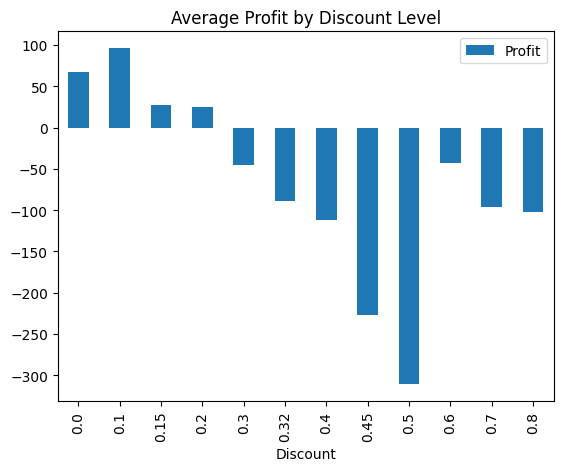

In [ ]:
# Visualization
discount_profit.plot(kind='bar')

plt.title('Average Profit by Discount Level')

plt.show()

### Insight
Average profit becomes negative when discount levels exceed 30%, indicating that aggressive discounting significantly impacts profitability.

# 11. Regional Performance Analysis
Compare profitability performance across regions.

In [ ]:
# Sales and profit by region
region_perf = (
    df.groupby('Region')
      .agg({
          'Sales':'sum',
          'Profit':'sum'
      })
)

region_perf

,Sales,Profit
Region,,
Central,501239.8908,39706.3625
East,678499.8680,91534.8388
South,391721.9050,46749.4303
West,725457.8245,108418.4489


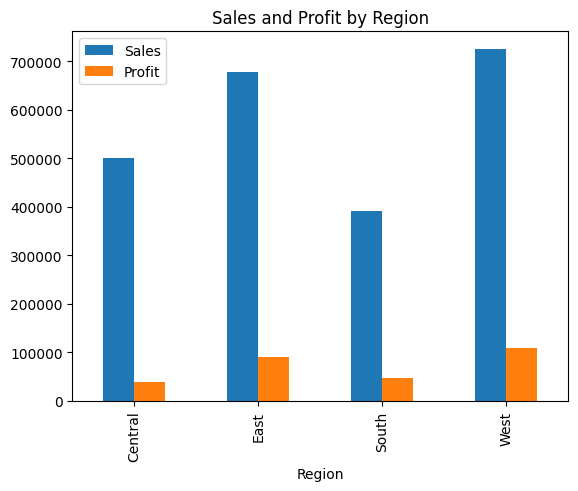

In [ ]:
# Visualization
region_perf.plot(kind='bar')

plt.title('Sales and Profit by Region')

plt.show()

### Insight
The West region generates the strongest profit performance, while other regions contribute lower profitability.

# 12. Key findings

- Technology is the most profitable category.
- Furniture generates the lowest profitability and profit margin.
- Tables is the largest loss-making sub-category.
- Higher discount levels significantly reduce profitability.
- Average profit turns negative when discounts exceed 30%.
- West region demonstrates the strongest profit performance.